Using device: cpu

=== Model Architecture Summary ===

Starting Model Training...
Epoch [1/5] - Average Loss: 0.6672
Epoch [2/5] - Average Loss: 0.3171
Epoch [3/5] - Average Loss: 0.2913
Epoch [4/5] - Average Loss: 0.2680
Epoch [5/5] - Average Loss: 0.2776

--- Test Set Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.24      0.38       234
   Pneumonia       0.68      1.00      0.81       390

    accuracy                           0.71       624
   macro avg       0.83      0.62      0.60       624
weighted avg       0.80      0.71      0.65       624



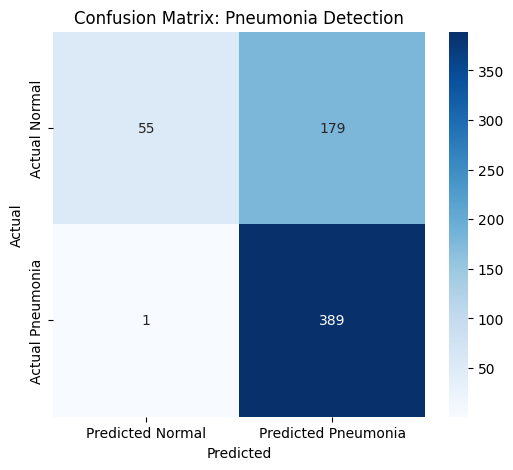

In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ১. হার্ডওয়্যার ডিভাইস কনফিগারেশন
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ২. ইমেজ প্রিপ্রসেসিং এবং অগমেন্টেশন
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

train_pipeline = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_test_pipeline = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ৩. ডেটাসেট লোড করা (রুট ডিরেক্টরি '.')
data_root = '.'
train_set = datasets.ImageFolder(
    os.path.join(data_root, 'train'), transform=train_pipeline
)
val_set = datasets.ImageFolder(
    os.path.join(data_root, 'val'), transform=val_test_pipeline
)
test_set = datasets.ImageFolder(
    os.path.join(data_root, 'test'), transform=val_test_pipeline
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


# ৪. কাস্টম কনভোল্যুশনাল নিউরাল নেটওয়ার্ক (CNN)
class ChestXRayClassifier(nn.Module):

  def __init__(self):
    super(ChestXRayClassifier, self).__init__()
    self.conv_blocks = nn.Sequential(
        # Block 1
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),  # 64x64
        # Block 2
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),  # 32x32
        # Block 3
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),  # 16x16
    )
    self.fc_head = nn.Sequential(
        nn.Dropout(0.35),
        nn.Linear(128 * 16 * 16, 128),
        nn.ReLU(),
        nn.Dropout(0.25),
        nn.Linear(128, 1),
    )

  def forward(self, x):
    features = self.conv_blocks(x)
    flattened = features.view(features.size(0), -1)
    return self.fc_head(flattened)


model = ChestXRayClassifier().to(device)

# --- বন্ধুর মতো মডেল সামারি টেবিল প্রিন্ট করা ---
try:
  from torchinfo import summary

  print('\n=== Model Architecture Summary ===')
  summary(model, input_size=(1, 3, 128, 128))
except ImportError:
  os.system('pip install -q torchinfo')
  from torchinfo import summary

  print('\n=== Model Architecture Summary ===')
  summary(model, input_size=(1, 3, 128, 128))

# ৫. লস ফাংশন এবং অপটিমাইজার
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.5]).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.0008)

# ৬. মডেল ট্রেনিং লুপ (৫ ইপক)
EPOCHS = 5
print('\nStarting Model Training...')
for epoch in range(EPOCHS):
  model.train()
  total_loss = 0.0
  for imgs, labels in train_loader:
    imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)
    optimizer.zero_grad()
    preds = model(imgs)
    loss = loss_fn(preds, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * imgs.size(0)
  print(
      f'Epoch [{epoch+1}/{EPOCHS}] - Average Loss:'
      f' {total_loss/len(train_set):.4f}'
  )

# ৭. টেস্ট সেটে ইভ্যালুয়েশন
model.eval()
all_labels, all_preds = [], []
with torch.no_grad():
  for imgs, labels in test_loader:
    imgs = imgs.to(device)
    outputs = model(imgs)
    predicted_classes = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()
    all_labels.extend(labels.numpy())
    all_preds.extend(predicted_classes.flatten())

print('\n--- Test Set Classification Report ---')
print(
    classification_report(
        all_labels, all_preds, target_names=['Normal', 'Pneumonia']
    )
)

# ৮. বন্ধুর মতো Confusion Matrix Heatmap ভিজ্যুয়ালাইজেশন
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Pneumonia'],
    yticklabels=['Actual Normal', 'Actual Pneumonia'],
)
plt.title('Confusion Matrix: Pneumonia Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [8]:
!pip install -q gdown
!gdown 1219EeGE1XTJVXYaulynJSa3BXGsbNCLx -O dataset.zip
!unzip -q dataset.zip
!ls -la

Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=aca3c486-c7c8-4811-a589-64b1e4ca31eb
To: /content/dataset.zip
100% 1.23G/1.23G [00:15<00:00, 81.5MB/s]
replace test/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
replace __MACOSX/test/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

total 1197284
drwxr-xr-x 1 root root       4096 Sep  9 07:09 .
drwxr-xr-x 1 root root       4096 Sep  9 04:38 ..
drwxr-xr-x 4 root root       4096 Aug 24 13:21 .config
-rw-r--r-- 1 root root 1225979251 Jan  8  2024 dataset.zip
drwxr-xr-x 4 root root       4096 Sep  9 04:44 __MACOSX
drwxr-xr-x 1 root root       4096 Aug 24 13:21 sample_data
drwxr-xr-x 4 root root       4096 Sep  9 07:10 test
drwxr-xr-x 4 root root       4096 Sep  9 07:10 train
drwxr-xr-x 4 root root       4096 Jan  8  2024 val


In [ ]:
import os

for root, dirs, files in os.walk('.'):
    if 'train' in dirs:
        print("Found your data_root at:", repr(root))
        break

Found your data_root at: '.'
